# 03 — Exploratory Data Analysis

Reads `data_features.csv` and visualises how each feature group separates the four age classes.

| Section | What to look for |
|---------|------------------|
| Readability | Flesch RE ↓ and FK Grade ↑ as age group rises |
| Linguistic | Longer sentences, richer vocab in older groups |
| Sensitivity | Profanity / adult scores spike sharply at +18 |
| Sentiment | Younger texts more positive; adult texts more complex |
| Correlation | Identify redundant features before model training |
| PCA | Distinct clusters = features are strong enough to separate classes |
| Feature importance | Top discriminative features to prioritise in model |

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi']     = 120

print('✅ Libraries loaded!')

✅ Libraries loaded!


## Load Features

In [2]:
df = pd.read_csv('data_features.csv')

# Normalise label format: ensure labels are '+4', '+10', '+12', '+18'
df['age_group'] = df['age_group'].astype(str).str.strip()
df['age_group'] = df['age_group'].apply(lambda x: '+' + x if not x.startswith('+') else x)

feature_cols = [c for c in df.columns if c != 'age_group']
age_order    = ['+4', '+10', '+12', '+18']
colors       = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
colors_map   = dict(zip(age_order, colors))

print(f'✅ Loaded {len(df):,} samples  |  {len(feature_cols)} features')
print('Age groups:', df['age_group'].unique().tolist())
print('Sample counts:', df['age_group'].value_counts().sort_index().to_dict())
df.head(3)

✅ Loaded 8,000 samples  |  23 features
Age groups: ['+10', '+4', '+12', '+18']
Sample counts: {'+10': 2000, '+12': 2000, '+18': 2000, '+4': 2000}


,age_group,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,dale_chall,smog_index,avg_sentence_length,vocab_richness,avg_word_length,long_word_ratio,...,profanity_score,adult_score,drug_score,sentiment_positive,sentiment_negative,sentiment_neutral,sentiment_compound,dialogue_ratio,exclamation_ratio,question_ratio
0,+10,60.358999,8.643317,10.344182,9.315259,11.362044,15.533333,0.753769,4.929648,0.266332,...,0.0,0.0,0.0,0.156,0.023,0.821,0.9648,0.243221,0.357143,0.071429
1,+10,63.280891,7.728724,8.522747,9.452064,9.725611,15.866667,0.743719,5.020101,0.266332,...,0.0,0.0,0.0,0.147,0.077,0.776,0.9319,0.069936,0.071429,0.142857
2,+4,94.655625,3.463780,5.694048,6.208239,6.182691,15.928571,0.520833,3.703125,0.052083,...,0.0,0.0,0.0,0.254,0.025,0.721,0.9940,0.259615,0.000000,0.000000


## 📖 Readability

We expect **Flesch Reading Ease to decrease** and **Gunning Fog / Dale-Chall to increase** as age group rises, confirming that older texts are linguistically more complex.

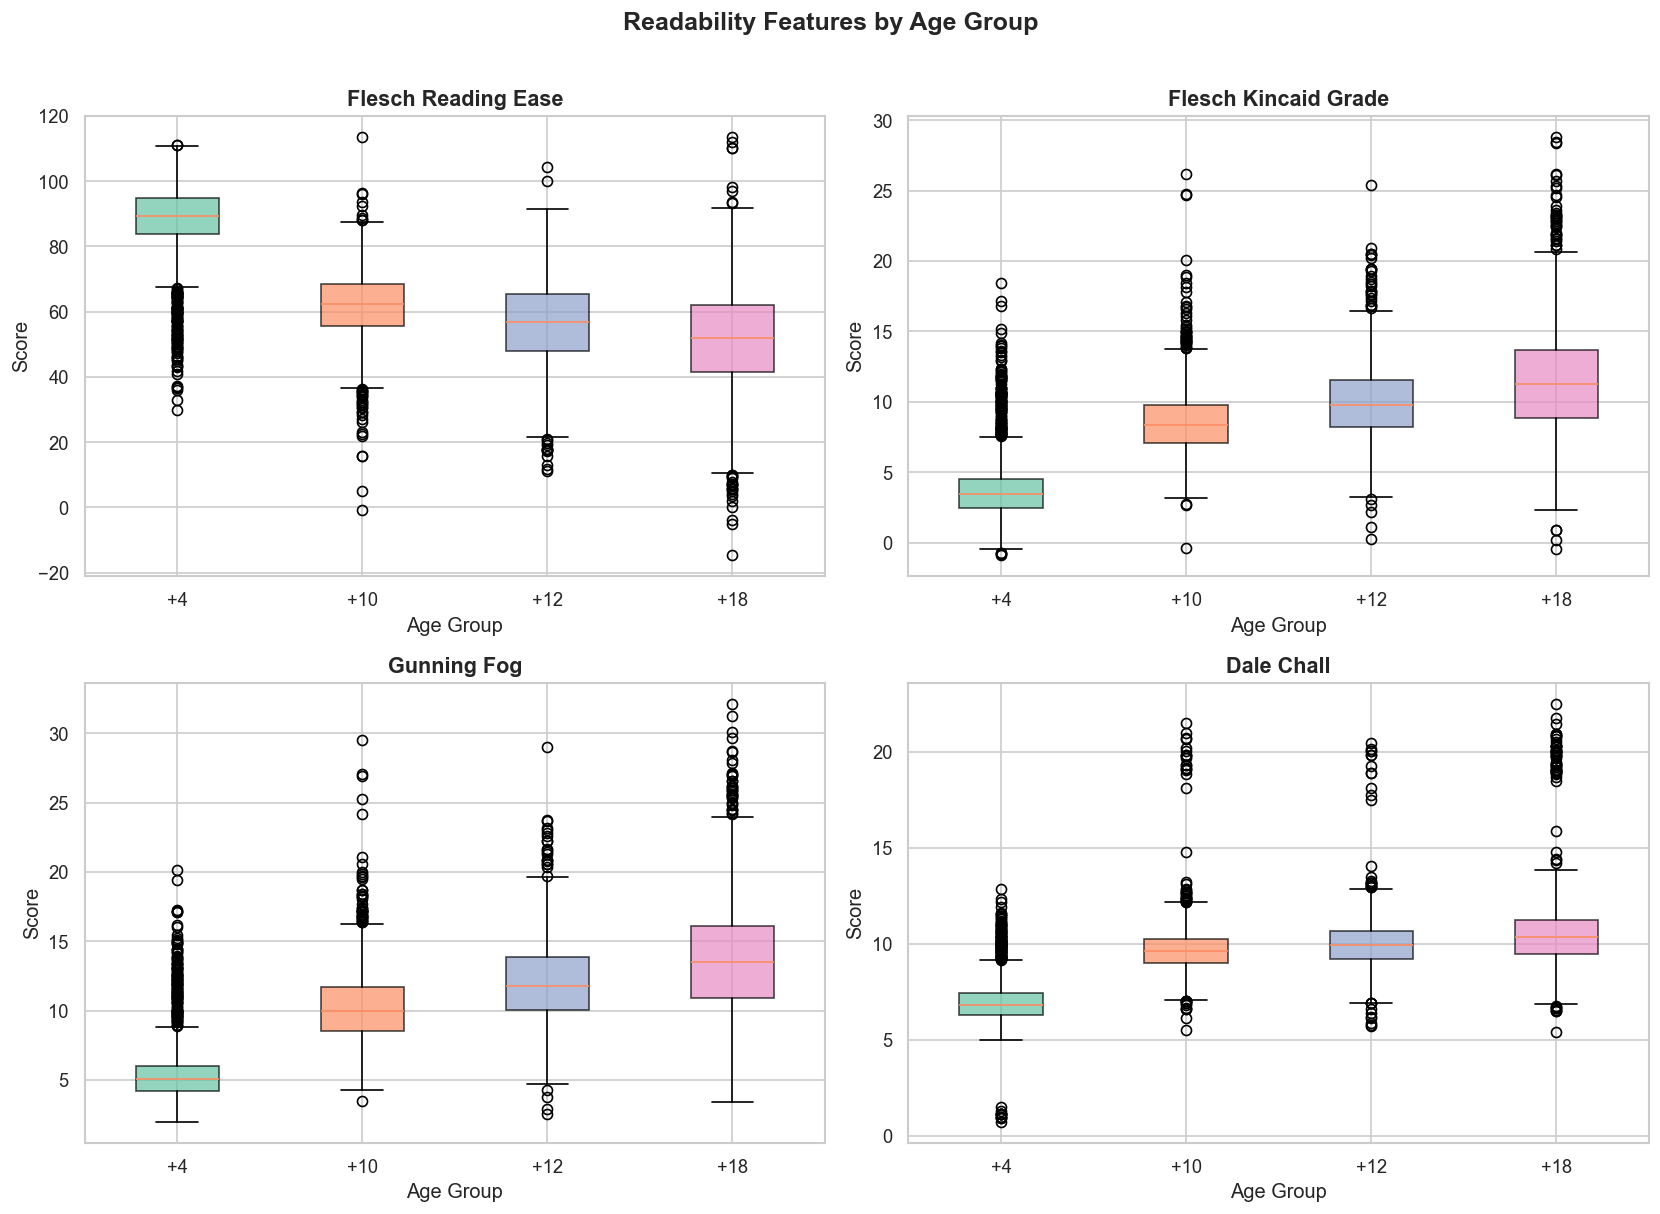

✅ Saved plot_readability.png


In [3]:
readability_cols = ['flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog', 'dale_chall']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(readability_cols):
    data_by_group = [df[df['age_group'] == g][col].dropna().values for g in age_order]
    bp = axes[i].boxplot(data_by_group, labels=age_order, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Age Group')
    axes[i].set_ylabel('Score')

plt.suptitle('Readability Features by Age Group', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_readability.png', bbox_inches='tight')
plt.show()
print('✅ Saved plot_readability.png')

## 📝 Linguistic

Older age groups should show **longer sentences, richer vocabulary and higher long-word ratios**, reflecting more sophisticated writing.

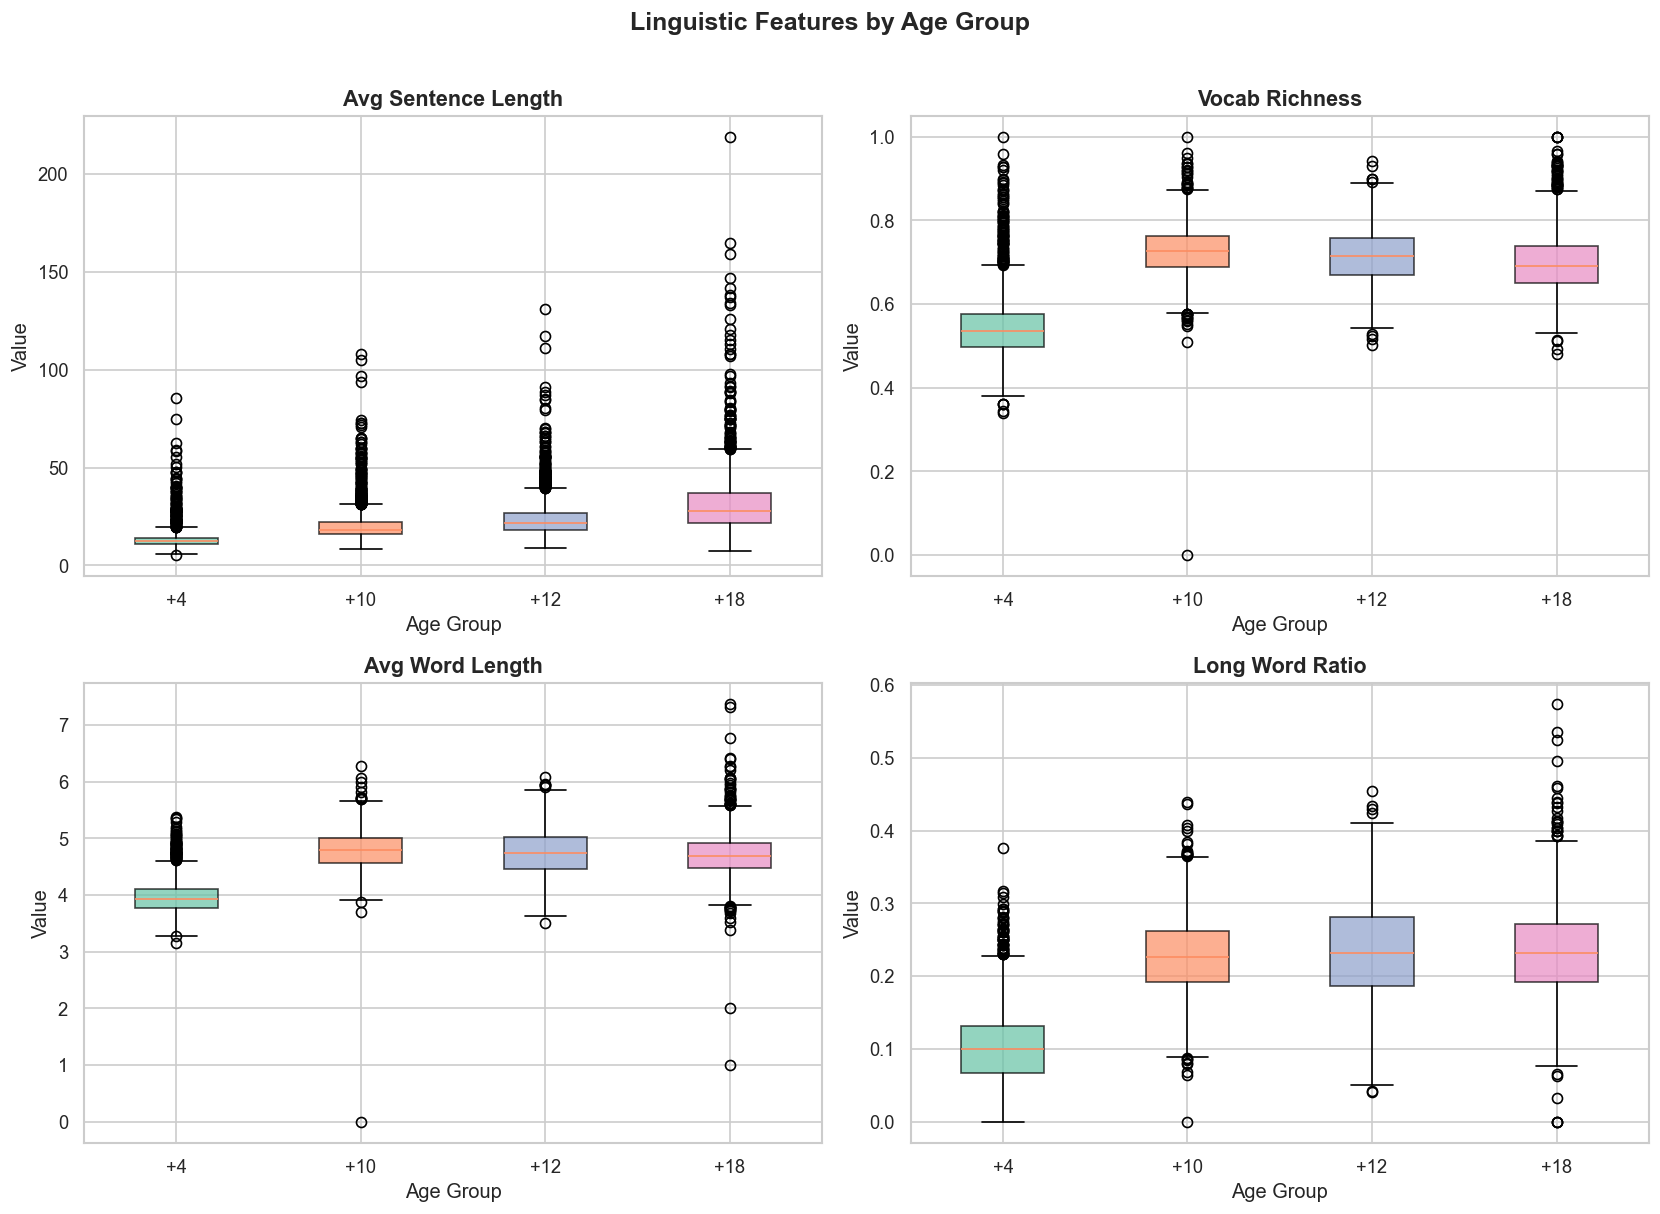

✅ Saved plot_linguistic.png


In [4]:
linguistic_cols = ['avg_sentence_length', 'vocab_richness', 'avg_word_length', 'long_word_ratio']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(linguistic_cols):
    data_by_group = [df[df['age_group'] == g][col].dropna().values for g in age_order]
    bp = axes[i].boxplot(data_by_group, labels=age_order, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Age Group')
    axes[i].set_ylabel('Value')

plt.suptitle('Linguistic Features by Age Group', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_linguistic.png', bbox_inches='tight')
plt.show()
print('✅ Saved plot_linguistic.png')

## ⚠️ Sensitivity

Sensitivity markers such as **profanity and adult content should increase notably in +18 texts**, validating their usefulness as classification features.

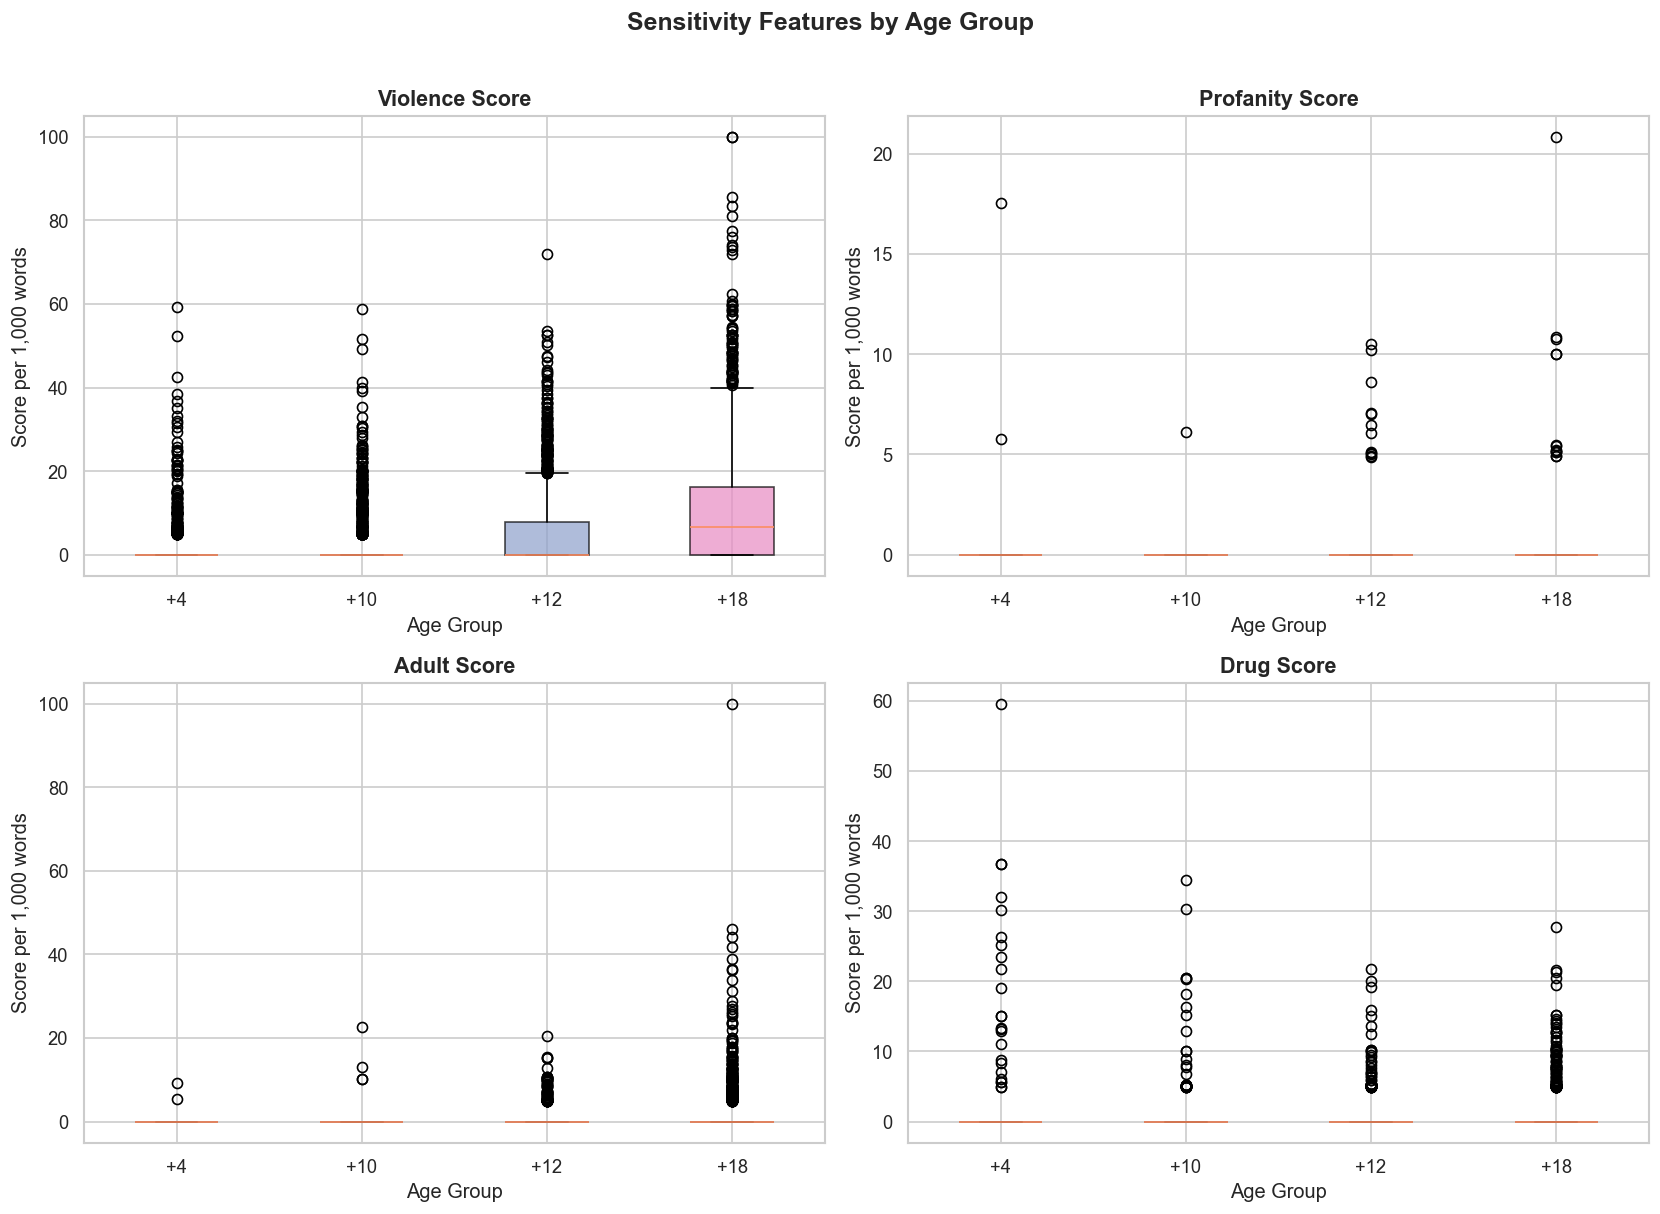

✅ Saved plot_sensitivity.png


In [5]:
sensitivity_cols = ['violence_score', 'profanity_score', 'adult_score', 'drug_score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(sensitivity_cols):
    data_by_group = [df[df['age_group'] == g][col].dropna().values for g in age_order]
    bp = axes[i].boxplot(data_by_group, labels=age_order, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Age Group')
    axes[i].set_ylabel('Score per 1,000 words')

plt.suptitle('Sensitivity Features by Age Group', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_sensitivity.png', bbox_inches='tight')
plt.show()
print('✅ Saved plot_sensitivity.png')

## 😊 Sentiment

Younger texts tend to be **more positive in tone**; adult texts may carry more emotional complexity and negativity.

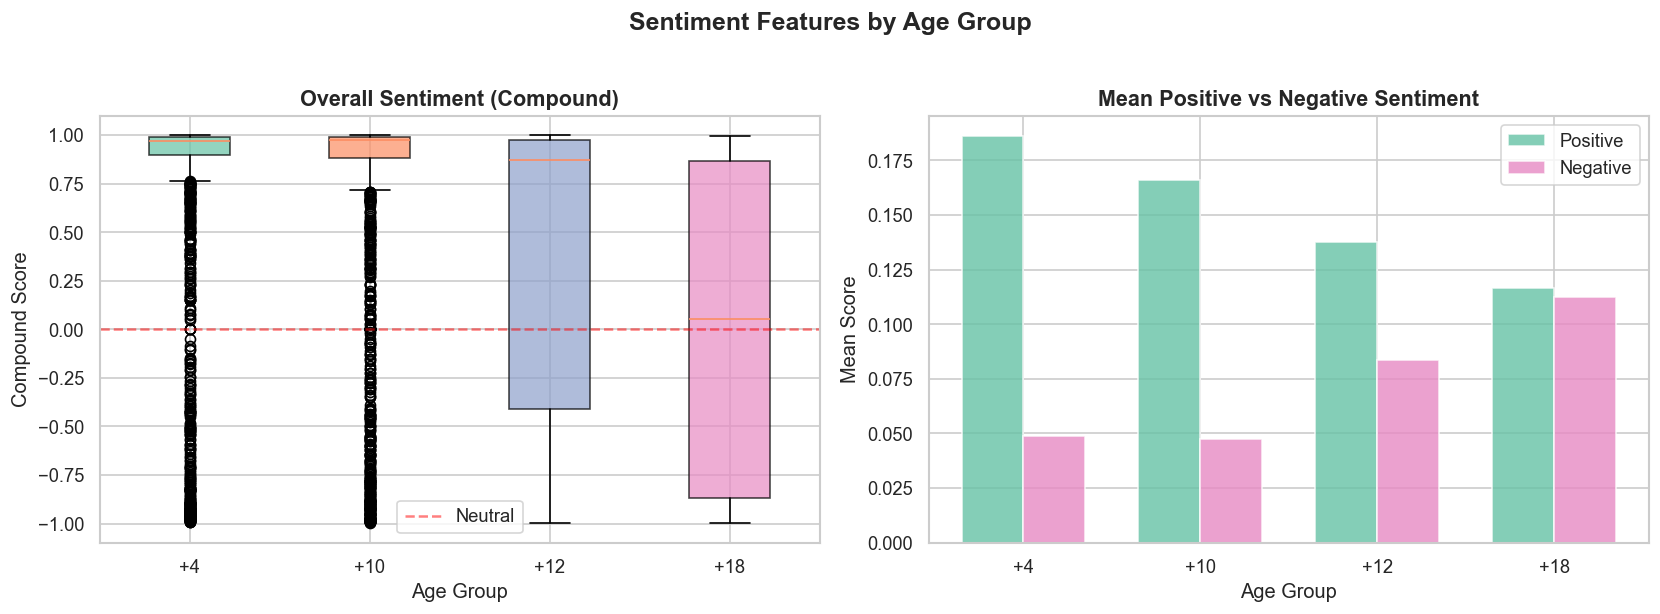

✅ Saved plot_sentiment.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compound sentiment boxplot
data_by_group = [df[df['age_group'] == g]['sentiment_compound'].dropna().values for g in age_order]
bp = axes[0].boxplot(data_by_group, labels=age_order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Overall Sentiment (Compound)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Compound Score')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5, label='Neutral')
axes[0].legend()

# Positive vs Negative mean bar chart
pos_means = [df[df['age_group'] == g]['sentiment_positive'].mean() for g in age_order]
neg_means = [df[df['age_group'] == g]['sentiment_negative'].mean() for g in age_order]
x = np.arange(len(age_order))
w = 0.35
axes[1].bar(x - w/2, pos_means, w, label='Positive', color='#66c2a5', alpha=0.8)
axes[1].bar(x + w/2, neg_means, w, label='Negative', color='#e78ac3', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(age_order)
axes[1].set_title('Mean Positive vs Negative Sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Mean Score')
axes[1].legend()

plt.suptitle('Sentiment Features by Age Group', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_sentiment.png', bbox_inches='tight')
plt.show()
print('✅ Saved plot_sentiment.png')

## 💬 Style Features

Dialogue and punctuation patterns reveal writing register — signals readability scores miss.

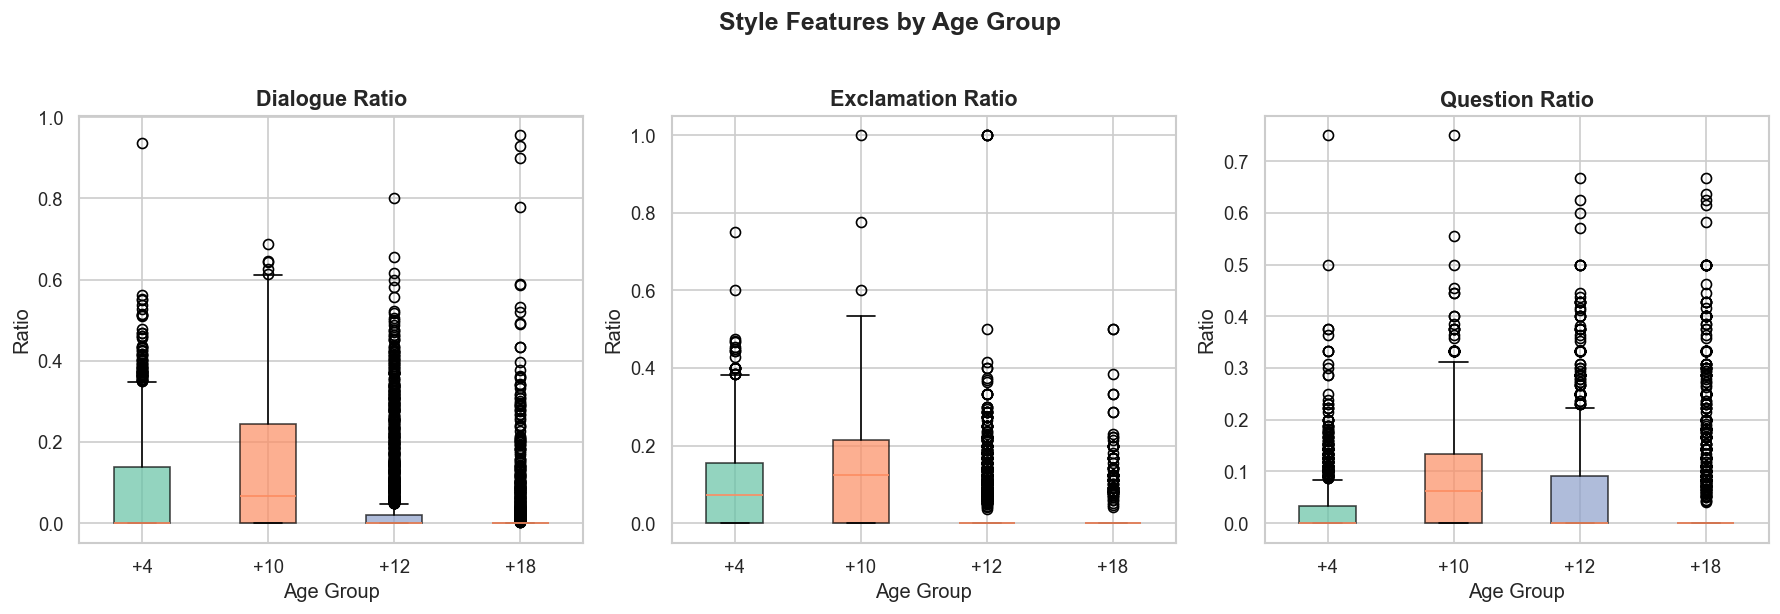

✅ Saved plot_style.png


In [7]:
style_cols = ['dialogue_ratio', 'exclamation_ratio', 'question_ratio']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(style_cols):
    data_by_group = [df[df['age_group'] == g][col].dropna().values for g in age_order]
    bp = axes[i].boxplot(data_by_group, labels=age_order, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Age Group')
    axes[i].set_ylabel('Ratio')

plt.suptitle('Style Features by Age Group', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_style.png', bbox_inches='tight')
plt.show()
print('✅ Saved plot_style.png')

## 🔥 Correlation Matrix

Highly correlated features (|r| > 0.8) may be redundant. This informs feature selection before model training.

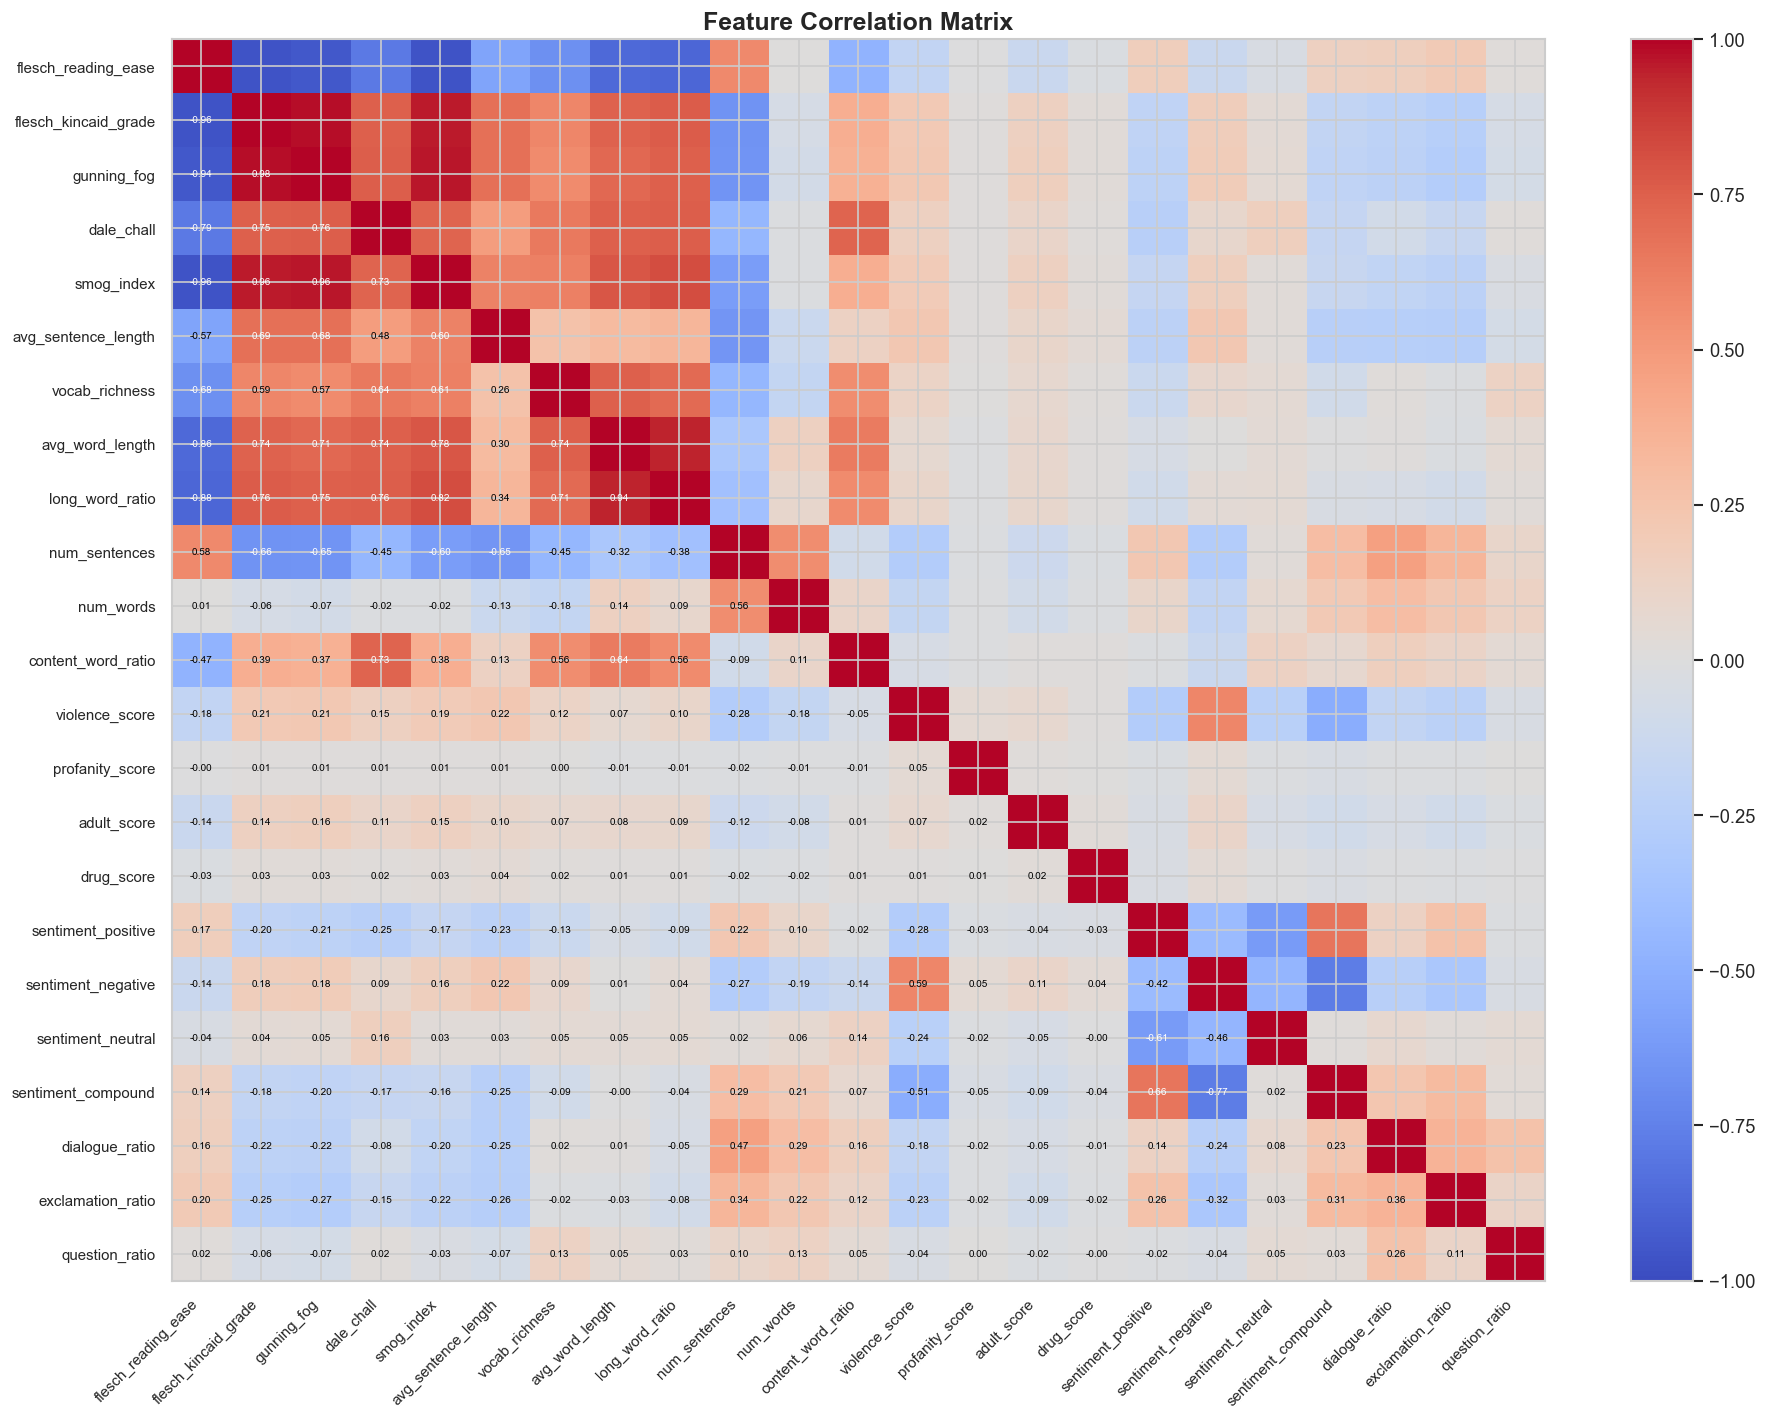

✅ Saved plot_correlation.png

⚠️  Highly correlated pairs (|r| > 0.8):
  flesch_kincaid_grade  ↔  gunning_fog  :  r = 0.984
  flesch_reading_ease  ↔  smog_index  :  r = -0.965
  gunning_fog  ↔  smog_index  :  r = 0.963
  flesch_reading_ease  ↔  flesch_kincaid_grade  :  r = -0.961
  flesch_kincaid_grade  ↔  smog_index  :  r = 0.958
  avg_word_length  ↔  long_word_ratio  :  r = 0.943
  flesch_reading_ease  ↔  gunning_fog  :  r = -0.942
  flesch_reading_ease  ↔  long_word_ratio  :  r = -0.875
  flesch_reading_ease  ↔  avg_word_length  :  r = -0.86
  smog_index  ↔  long_word_ratio  :  r = 0.817


In [8]:
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
im = plt.imshow(corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(feature_cols)), feature_cols, rotation=45, ha='right', fontsize=9)
plt.yticks(range(len(feature_cols)), feature_cols, fontsize=9)

for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        if not mask[i, j]:
            plt.text(j, i, f'{corr.iloc[i, j]:.2f}',
                     ha='center', va='center', fontsize=6,
                     color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')

plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation.png', bbox_inches='tight')
plt.show()
print('✅ Saved plot_correlation.png')

# Print highly correlated pairs
print('\n⚠️  Highly correlated pairs (|r| > 0.8):')
high_corr = [(feature_cols[i], feature_cols[j], round(corr.iloc[i, j], 3))
             for i in range(len(feature_cols))
             for j in range(i+1, len(feature_cols))
             if abs(corr.iloc[i, j]) > 0.8]
for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f'  {a}  ↔  {b}  :  r = {r}')

## 🔵 PCA

If age groups form distinct clusters in 2D, our features are strong enough to separate them. The more separated the clusters, the easier the classification task.

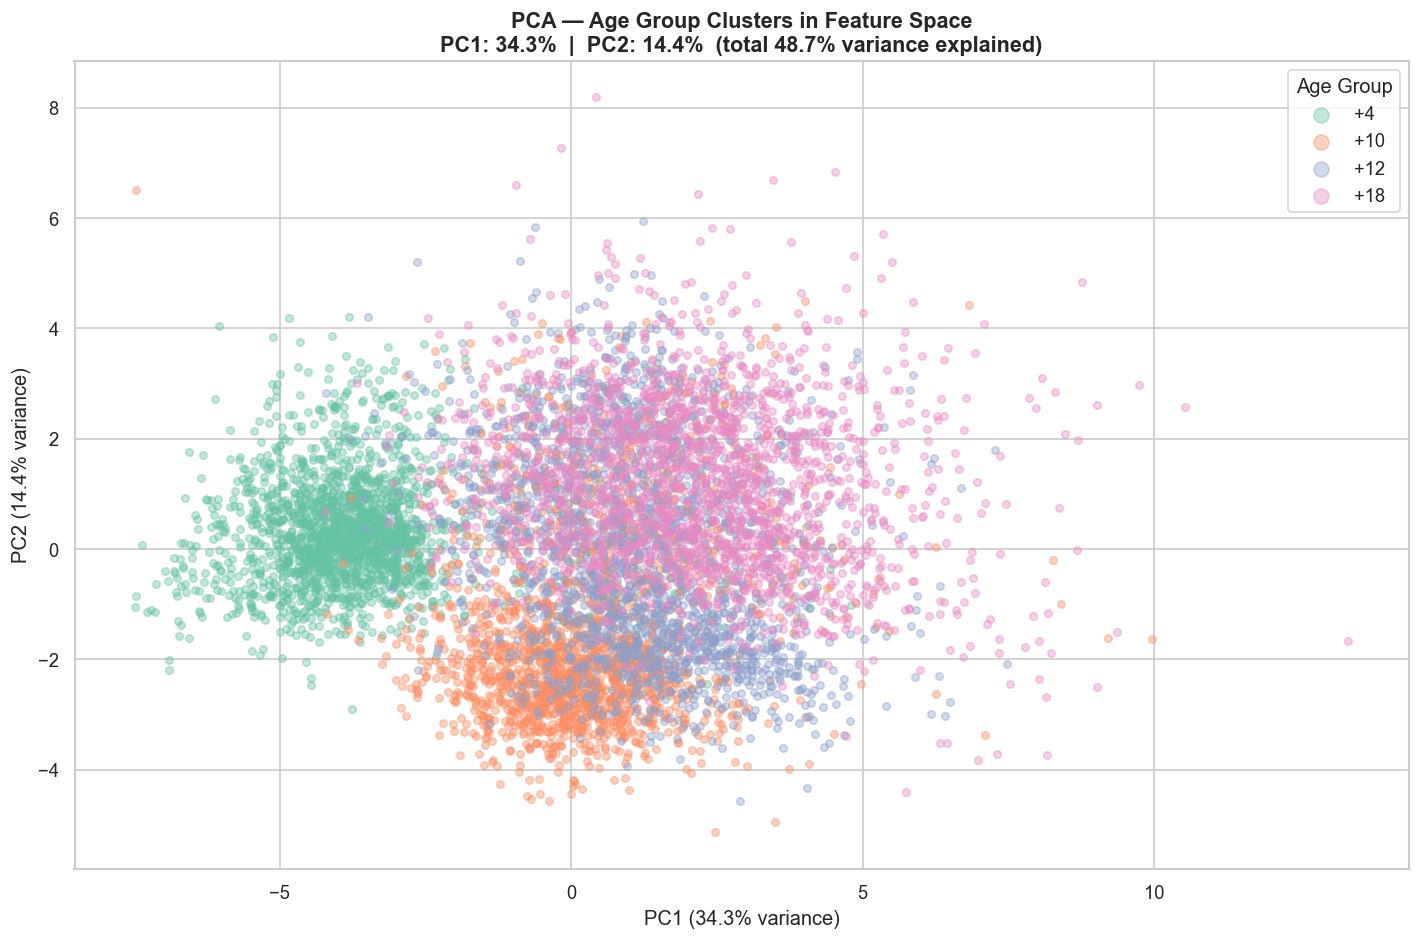

✅ Saved plot_pca.png

Top 8 features driving PC1 (strongest separation axis):
flesch_reading_ease     0.3422
flesch_kincaid_grade    0.3379
gunning_fog             0.3356
smog_index              0.3350
dale_chall              0.3030
long_word_ratio         0.3028
avg_word_length         0.2945
vocab_richness          0.2582


In [9]:
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

pca    = PCA(n_components=2)
X_pca  = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(12, 8))
for group in age_order:
    mask = df['age_group'] == group
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors_map[group], label=group, alpha=0.4, s=20)

plt.title(f'PCA — Age Group Clusters in Feature Space\n'
          f'PC1: {var_explained[0]:.1f}%  |  PC2: {var_explained[1]:.1f}%  '
          f'(total {sum(var_explained):.1f}% variance explained)',
          fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
plt.legend(title='Age Group', markerscale=2)
plt.tight_layout()
plt.savefig('plot_pca.png', bbox_inches='tight')
plt.show()
print('✅ Saved plot_pca.png')

# PCA loadings — which features drive PC1?
loadings = pd.Series(pca.components_[0], index=feature_cols).abs().sort_values(ascending=False)
print('\nTop 8 features driving PC1 (strongest separation axis):')
print(loadings.head(8).round(4).to_string())

## 📊 Feature Importance Summary

Features with the highest mean range across age groups are the most discriminative — these will be most useful in the model.

📊 Top 10 most discriminative features:
age_group                   +4       +10       +12       +18
flesch_reading_ease    88.1123   61.8300   56.2705   51.6229
num_words             148.4325  173.7615  168.4965  138.2450
avg_sentence_length    13.3693   20.5079   24.1311   31.4286
violence_score          0.9279    1.9608    5.2370   10.6026
num_sentences          14.7210   11.6335    9.3775    6.0630
gunning_fog             5.4311   10.2672   11.9472   13.7286
flesch_kincaid_grade    3.7336    8.5727    9.8854   11.4389
smog_index              6.7628   10.8431   11.8676   12.8745
dale_chall              6.9495    9.7151    9.9801   10.5296
adult_score             0.0073    0.0281    0.2577    1.2964


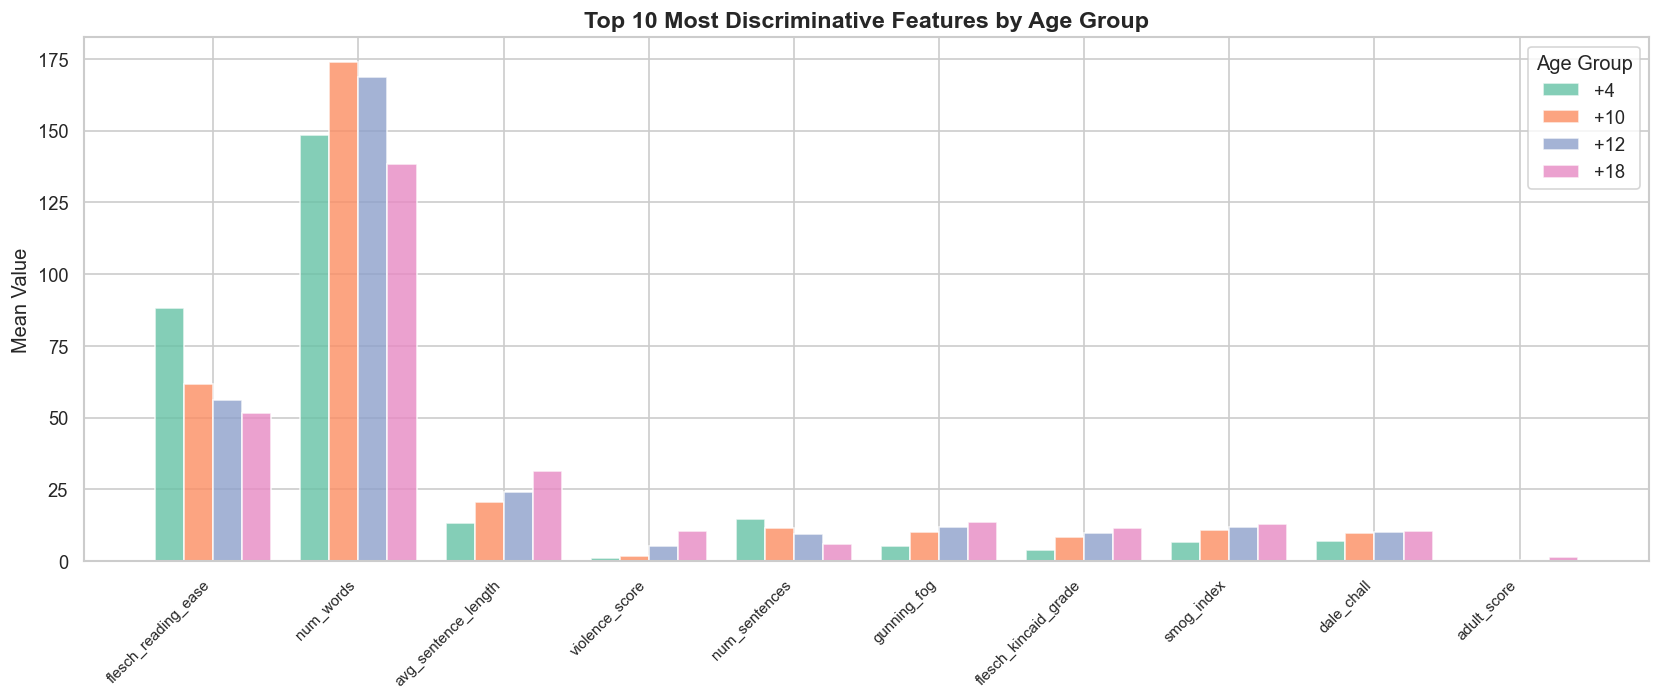

✅ Saved plot_feature_importance.png


In [10]:
summary = df.groupby('age_group')[feature_cols].mean().T
summary = summary.reindex(columns=age_order)
summary['range'] = summary.max(axis=1) - summary.min(axis=1)
summary_sorted = summary.sort_values('range', ascending=False)

print('📊 Top 10 most discriminative features:')
print(summary_sorted[age_order].head(10).round(4).to_string())

top10 = summary_sorted.head(10)
fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(top10))
width = 0.2

for i, group in enumerate(age_order):
    ax.bar(x + i * width, top10[group], width,
           label=group, color=colors[i], alpha=0.8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(top10.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Top 10 Most Discriminative Features by Age Group',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Value')
ax.legend(title='Age Group')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()
print('✅ Saved plot_feature_importance.png')